# Logistic Regression

In [65]:
import numpy as np
import pandas as pd

In [66]:
from sklearn.datasets import load_breast_cancer

In [67]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
from sklearn.linear_model import LogisticRegression

In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## Load Dataset

In [71]:
data = load_breast_cancer()

In [72]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

In [73]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [74]:
y.head()


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [76]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(426, 30)
(143, 30)
(426,)
(143,)


## Feature Scaling (Standardization)

In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
X_train_scaled


array([[ 1.65909581,  0.21720545,  1.6106199 , ...,  0.70183483,
        -0.55608415,  0.38878074],
       [-0.33816539, -1.38996798, -0.40166719, ..., -0.90060625,
        -0.92364564, -0.79723299],
       [ 0.87445748, -0.65165862,  1.01036969, ...,  2.09675055,
         1.76721075,  1.16521656],
       ...,
       [ 0.39511479,  1.04780348,  0.50533158, ...,  1.52062207,
         0.15453473,  1.20793655],
       [ 0.84877841, -0.04840585,  0.90273861, ...,  2.08632962,
         0.30155932,  0.34873075],
       [-1.22637597, -0.51885297, -1.20434661, ..., -0.9053701 ,
        -0.58058825,  0.03206882]])

## Train Logistic Regression

In [79]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [80]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="f1")

In [81]:
y_pred = model.predict(X_test_scaled)

In [82]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [83]:
accuracy = accuracy_score(y_test, y_pred)

In [84]:
accuracy

0.986013986013986

In [85]:
model.coef_

array([[-0.5230639 , -0.51866977, -0.48369147, -0.55733419, -0.3010073 ,
         0.69423027, -0.56544331, -0.6769288 , -0.12623296,  0.08371349,
        -1.0701021 ,  0.26071433, -0.49107245, -0.94105896, -0.14558343,
         0.61642565,  0.15410769, -0.34398572,  0.42510152,  0.37488172,
        -0.91747951, -1.25014919, -0.72116803, -0.92581178, -0.6696476 ,
         0.04658657, -0.79675795, -0.94188817, -0.95704524, -0.20956757]])

=== Optimization Results ===
Best Hyperparameters: {'knn__n_neighbors': 17, 'knn__p': 2, 'knn__weights': 'distance'}
Best Cross-Validation Accuracy: 97.50%

=== Test Set Evaluation ===
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.9000    0.9474        10
   virginica     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



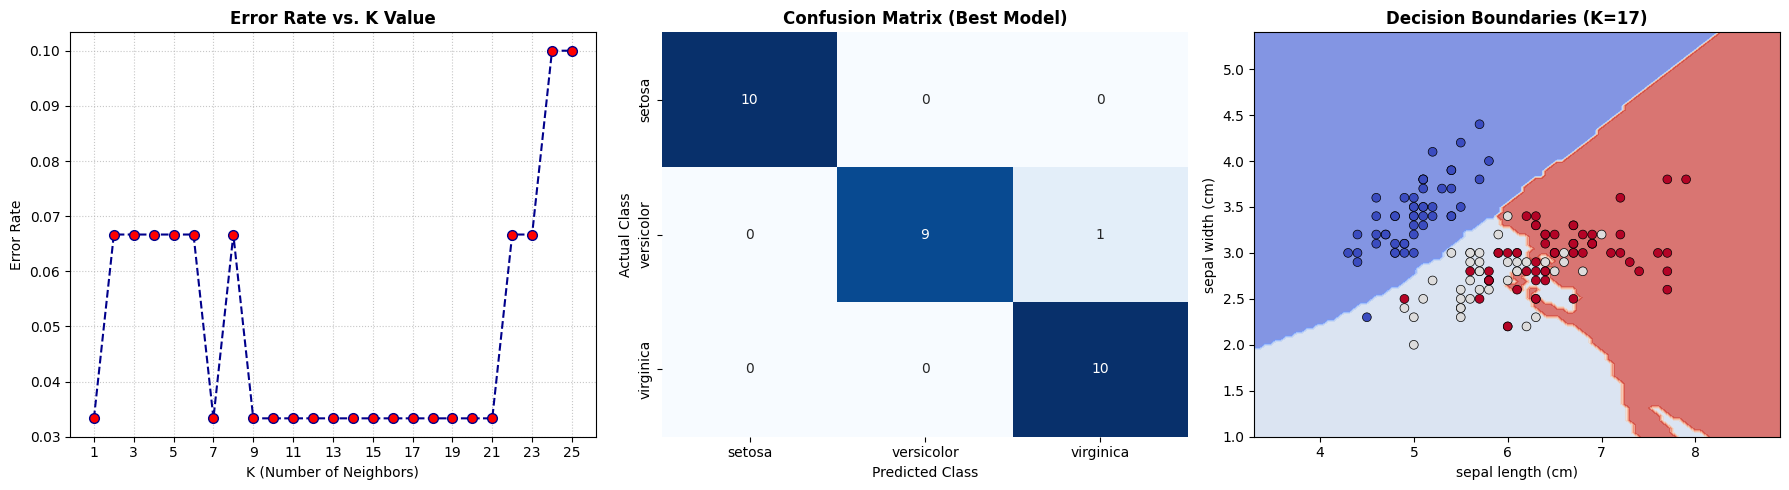

In [89]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

# =====================================================================
# Step 1: Load and Prepare Data
# =====================================================================
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Train/Test Split (80% train, 20% test with stratified sampling)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================================================
# Step 2: Build the Pipeline
# =====================================================================
# The pipeline pairs feature scaling with the KNN classifier.
knn_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier()),
    ]
)

# =====================================================================
# Step 3: Hyperparameter Tuning via GridSearchCV
# =====================================================================
# Define parameter search grid
param_grid = {
    "knn__n_neighbors": list(range(1, 26)),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],  # p=1 (Manhattan distance), p=2 (Euclidean distance)
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
print("=== Optimization Results ===")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(
    f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%\n"
)

# =====================================================================
# Step 4: Model Evaluation on Test Set
# =====================================================================
y_pred = best_pipeline.predict(X_test)

print("=== Test Set Evaluation ===")
print(
    classification_report(y_test, y_pred, target_names=target_names, digits=4)
)

# =====================================================================
# Step 5: Visualizations
# =====================================================================
plt.figure(figsize=(18, 5))

# Plot 1: Test Error Rate vs. K Value
k_range = list(range(1, 26))
error_rates = []

for k in k_range:
    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k)),
        ]
    )
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    error_rates.append(np.mean(preds != y_test))

plt.subplot(1, 3, 1)
plt.plot(
    k_range,
    error_rates,
    color="darkblue",
    linestyle="--",
    marker="o",
    markerfacecolor="red",
    markersize=7,
)
plt.title("Error Rate vs. K Value", fontsize=12, fontweight="bold")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Error Rate")
plt.xticks(range(1, 26, 2))
plt.grid(True, linestyle=":", alpha=0.7)

# Plot 2: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.subplot(1, 3, 2)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("Confusion Matrix (Best Model)", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

# Plot 3: 2D Decision Boundary
# Extract first two features (Sepal Length & Sepal Width) for visualization
X_2d = X[:, :2]
X_tr_2d, X_te_2d, y_tr_2d, y_te_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

pipe_2d = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=grid_search.best_params_["knn__n_neighbors"]
            ),
        ),
    ]
)
pipe_2d.fit(X_tr_2d, y_tr_2d)

plt.subplot(1, 3, 3)
DecisionBoundaryDisplay.from_estimator(
    pipe_2d,
    X_2d,
    response_method="predict",
    cmap=plt.cm.coolwarm,
    alpha=0.7,
    ax=plt.gca(),
    xlabel=feature_names[0],
    ylabel=feature_names[1],
)

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y,
    cmap=plt.cm.coolwarm,
    edgecolors="k",
    linewidth=0.5,
    s=40,
)
plt.title(
    f"Decision Boundaries (K={grid_search.best_params_['knn__n_neighbors']})",
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()
plt.show()